📍 El objetivo de este notebook es aplicar de manegra integral CountVectorizer, TFIDVectorizer y finalizar con un pipeline de Evaluación y Clasificación. El corpus a procesar se obtendrá utilizando el modelo Gemini de Google.


---



# 1. GEMINI API

In [ ]:
# Importar librería `google-generativeai`
from google.colab import userdata
import os

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

In [ ]:

from google import genai
from google.genai import types

cliente = genai.Client(api_key=GOOGLE_API_KEY)

In [ ]:
MODEL_ID = "gemini-2.0-flash" # @param ["gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-flash-preview-05-20","gemini-2.5-pro-preview-05-06"] {"allow-input":true, isTemplate: true}

In [ ]:
texto_entrada = "muy rico el asado, la carne jugosa"

In [ ]:
pregunta = f"""Redacta tres oraciones similares al texto proporcionado, mencionando al asado:

Texto: {texto_entrada}
"""

respuesta = cliente.models.generate_content(
    model=MODEL_ID,
    contents=[pregunta]
)
print(respuesta.text)

Aquí tienes tres oraciones similares a "muy rico el asado, la carne jugosa":

*   Delicioso el asado, con esa costra crocante.
*   Exquisito el asado, un sabor ahumado inigualable.
*   Tremendo asado, cada bocado era una fiesta.



In [ ]:
pregunta = f"""Redacta tres oraciones similares al texto proporcionado, mencionando al asado pero con variantes negativas:

Texto: {texto_entrada}
"""

respuesta_dos = cliente.models.generate_content(
    model=MODEL_ID,
    contents=[pregunta]
)

print(respuesta_dos.text)

Aquí hay tres oraciones similares al texto original, pero con connotaciones negativas sobre el asado:

1.  De rico no tuvo nada el asado, la carne estaba seca como una pasa.
2.  Lejos de ser jugoso, el asado resultó duro y difícil de masticar.
3.  Si bien era un asado, la carne no tenía sabor y dejaba mucho que desear.



# 2. CountVectorizer (Bag-of-Words) vs TfidfVectorizer

In [ ]:
# Importar las librerías
import re
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
corpus = []

for r in respuesta.text.split("\n"):
  corpus.append(r)

for r in respuesta_dos.text.split("\n"):
  corpus.append(r)

In [ ]:
corpus = []

for r in respuesta.text.split("\n"):
  # Remover numeros y caracteres especiales como *
  r = re.sub(r'\d+', '', r)
  r = re.sub(r'\*', '', r)
  r = r.strip()
  corpus.append(r)

for r in respuesta_dos.text.split("\n"):
  r = re.sub(r'\d+', '', r)
  r = re.sub(r'\*\.', '', r)
  r = r.strip()
  corpus.append(r)

In [ ]:
corpus

['Aquí tienes tres oraciones similares a "muy rico el asado, la carne jugosa":',
 '',
 'Delicioso el asado, con esa costra crocante.',
 'Exquisito el asado, un sabor ahumado inigualable.',
 'Tremendo asado, cada bocado era una fiesta.',
 '',
 'Aquí hay tres oraciones similares al texto original, pero con connotaciones negativas sobre el asado:',
 '',
 '.  De rico no tuvo nada el asado, la carne estaba seca como una pasa.',
 '.  Lejos de ser jugoso, el asado resultó duro y difícil de masticar.',
 '.  Si bien era un asado, la carne no tenía sabor y dejaba mucho que desear.',
 '']

In [ ]:
texto_uno = corpus[2:5]
texto_dos = corpus[8:11]
corpus = texto_uno + texto_dos
print(corpus)

['Delicioso el asado, con esa costra crocante.',
 'Exquisito el asado, un sabor ahumado inigualable.',
 'Tremendo asado, cada bocado era una fiesta.',
 '.  De rico no tuvo nada el asado, la carne estaba seca como una pasa.',
 '.  Lejos de ser jugoso, el asado resultó duro y difícil de masticar.',
 '.  Si bien era un asado, la carne no tenía sabor y dejaba mucho que desear.']

In [ ]:
# 1. Usando CountVectorizer (Bolsa de Palabras simple)
print("• CountVectorizer (BoW) •")
print("_" * 80)
count_vectorizer = CountVectorizer()
bow_matrix = count_vectorizer.fit_transform(corpus)

# Mostramos el vocabulario (las "features")
print("Vocabulario (Features):")
print(count_vectorizer.get_feature_names_out())
print("\n")

# Mostramos la matriz BoW (dispersa)
print("\nMatriz BoW (Documento x Palabra):")
print(bow_matrix.toarray())
print("_" * 80)

• CountVectorizer (BoW) •
________________________________________________________________________________
Vocabulario (Features):
['ahumado' 'asado' 'bien' 'bocado' 'cada' 'carne' 'como' 'con' 'costra'
 'crocante' 'de' 'dejaba' 'delicioso' 'desear' 'difícil' 'duro' 'el' 'era'
 'esa' 'estaba' 'exquisito' 'fiesta' 'inigualable' 'jugoso' 'la' 'lejos'
 'masticar' 'mucho' 'nada' 'no' 'pasa' 'que' 'resultó' 'rico' 'sabor'
 'seca' 'ser' 'si' 'tenía' 'tremendo' 'tuvo' 'un' 'una']



Matriz BoW (Documento x Palabra):
[[0 1 0 0 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0
  0 0 0 0 0 1 0]
 [0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 1 0 0 1]
 [0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 1
  0 0 0 0 1 0 1]
 [0 1 0 0 0 0 0 0 0 0 2 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0
  1 0 0 0 0 0 0]
 [0 1 1 0 0 1 0 0 0 0 0 1 0 1 

In [ ]:
# 2. Usando TfidfVectorizer
print("\n • TfidfVectorizer •")
tfidf_vectorizer = TfidfVectorizer()
print("_" * 80)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
print('\n')

# Mostramos la matriz TF-IDF
print("Matriz TF-IDF (Documento x Palabra):")
print(tfidf_matrix.toarray())
print("_" * 80)


 • TfidfVectorizer •
________________________________________________________________________________


Matriz TF-IDF (Documento x Palabra):
[[0.         0.1884417  0.         0.         0.         0.
  0.         0.42451449 0.42451449 0.42451449 0.         0.
  0.42451449 0.         0.         0.         0.2518471  0.
  0.42451449 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.        ]
 [0.45203772 0.20065925 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.26817551 0.
  0.         0.         0.45203772 0.         0.45203772 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.3706774  0.
  0.         0.         0.         0.         0.         0.37067

In [ ]:
# Obtener las features en el objeto 'vocabulario_tfid'
vocabulario_tfidf = tfidf_vectorizer.get_feature_names_out()
print("Vocabulario (TF-IDF):")
print(vocabulario_tfidf)

# Crear DataFrame para TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vocabulario_tfidf, index=[f"Doc_{i+1}" for i in range(len(corpus))])
print("\nMatriz TF-IDF (Documento-Término):")
# Redondear para mejor visualización
print(tfidf_df.round(3))

Vocabulario (TF-IDF):
['ahumado' 'asado' 'bien' 'bocado' 'cada' 'carne' 'como' 'con' 'costra'
 'crocante' 'de' 'dejaba' 'delicioso' 'desear' 'difícil' 'duro' 'el' 'era'
 'esa' 'estaba' 'exquisito' 'fiesta' 'inigualable' 'jugoso' 'la' 'lejos'
 'masticar' 'mucho' 'nada' 'no' 'pasa' 'que' 'resultó' 'rico' 'sabor'
 'seca' 'ser' 'si' 'tenía' 'tremendo' 'tuvo' 'un' 'una']

Matriz TF-IDF (Documento-Término):
       ahumado  asado   bien  bocado   cada  carne   como    con  costra  \
Doc_1    0.000  0.188  0.000   0.000  0.000  0.000  0.000  0.425   0.425   
Doc_2    0.452  0.201  0.000   0.000  0.000  0.000  0.000  0.000   0.000   
Doc_3    0.000  0.189  0.000   0.425  0.425  0.000  0.000  0.000   0.000   
Doc_4    0.000  0.134  0.000   0.000  0.000  0.248  0.303  0.000   0.000   
Doc_5    0.000  0.139  0.000   0.000  0.000  0.000  0.000  0.000   0.000   
Doc_6    0.000  0.132  0.298   0.000  0.000  0.245  0.000  0.000   0.000   

       crocante  ...   rico  sabor   seca    ser     si  tenía

<Axes: >

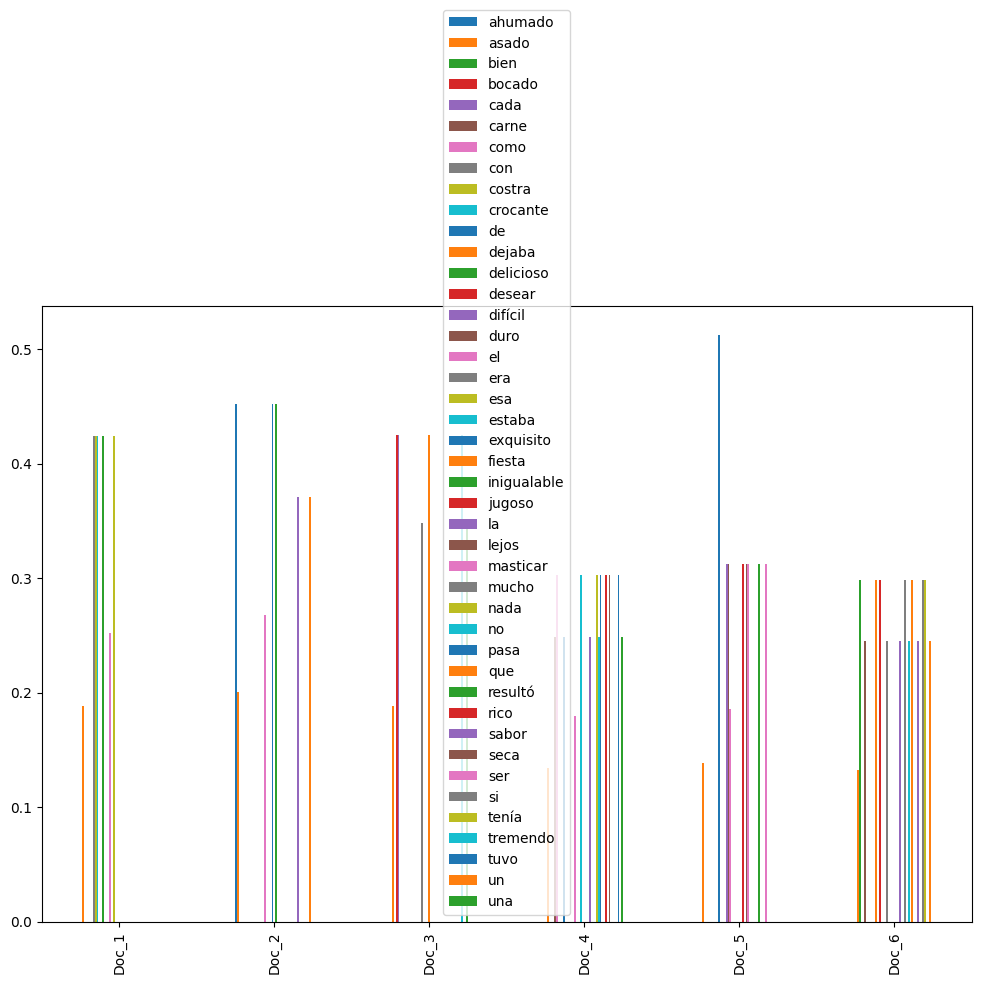

In [ ]:
# Grafico de barras con las features de la matriz TF-IDF
tfidf_df.plot(kind='bar', figsize=(12, 8) x = '')

Comparacion entre BoW y TF-IDF

In [ ]:
vectorizer_bow_for_compare = CountVectorizer(vocabulary=vocabulario_tfidf)
bow_matrix_for_compare = vectorizer_bow_for_compare.fit_transform(corpus)
bow_df_for_compare = pd.DataFrame(bow_matrix_for_compare.toarray(), columns=vocabulario_tfidf, index=[f"Doc_{i+1}" for i in range(len(corpus))])

In [ ]:
print(" • Comparación BoW vs TF-IDF •")
print('_' * 30)
print("\nMatriz Bag-of-Words (Revisada con vocabulario TF-IDF):")
print(bow_df_for_compare)

print("\nMatriz TF-IDF:")
print(tfidf_df.round(3))

 • Comparación BoW vs TF-IDF •
______________________________

Matriz Bag-of-Words (Revisada con vocabulario TF-IDF):
       ahumado  asado  bien  bocado  cada  carne  como  con  costra  crocante  \
Doc_1        0      1     0       0     0      0     0    1       1         1   
Doc_2        1      1     0       0     0      0     0    0       0         0   
Doc_3        0      1     0       1     1      0     0    0       0         0   
Doc_4        0      1     0       0     0      1     1    0       0         0   
Doc_5        0      1     0       0     0      0     0    0       0         0   
Doc_6        0      1     1       0     0      1     0    0       0         0   

       ...  rico  sabor  seca  ser  si  tenía  tremendo  tuvo  un  una  
Doc_1  ...     0      0     0    0   0      0         0     0   0    0  
Doc_2  ...     0      1     0    0   0      0         0     0   1    0  
Doc_3  ...     0      0     0    0   0      0         1     0   0    1  
Doc_4  ...     1      

In [ ]:
print("\n • Análisis •")
# Ejemplo: Palabra 'ahumado'
print("\n-Palabra: 'ahumado'")
print("  BoW  : ", bow_df_for_compare['ahumado'].values)
print("  TF-IDF: ", tfidf_df['ahumado'].round(3).values)
# La palabra 'ahumado' y posee  el máximo peso TF-IDF, porque aparece solo en documento 1.
print('_' * 50)
# Ejemplo 2: Palabra 'asado'
print("\n-Palabra: 'asado'")
print("  BoW  : ", bow_df_for_compare['asado'].values)
print("  TF-IDF: ", tfidf_df['asado'].round(3).values)
# La palabra 'asado' posee un peso TF-IDF > 0, pero aparece en todos los documentos.


 • Análisis •

-Palabra: 'ahumado'
  BoW  :  [0 1 0 0 0 0]
  TF-IDF:  [0.    0.452 0.    0.    0.    0.   ]
__________________________________________________

-Palabra: 'asado'
  BoW  :  [1 1 1 1 1 1]
  TF-IDF:  [0.188 0.201 0.189 0.134 0.139 0.132]


`CountVectorizer() `genera un modelo Bolsa de Palabras, tomando en cuenta la frecuencia de cada token(palabra), sin considerar el orden o estructura gramatical. Por su parte, la técnica `TfidVectorizer()`, al convertir las features en una matriz TF-IDF, el peso se ajusta por la importancia de un término dentro de un documento específico, a la vez que reduce la importancia de los términos comunes que son menos informativos.




Añadiendo N-Gramas a TF-IDF

In [ ]:
# • Añadiendo N-Gramas a TF-IDF •
print("_" * 20)
print("\n • TfidfVectorizer con N-Gramas (bigramas) •")
print("_" * 80)

# Usamos el mismo corpus de antes
# Creamos un nuevo vectorizador, ahora especificando ngram_range
tfidf_ngram_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
tfidf_ngram_matrix = tfidf_ngram_vectorizer.fit_transform(corpus)

# Mostramos el NUEVO vocabulario, que ahora incluye bigramas
print("Vocabulario con unigramas y bigramas:")
print(tfidf_ngram_vectorizer.get_feature_names_out())
print("\n")
# Mostramos la nueva matriz TF-IDF (será más ancha)
print("\nMatriz TF-IDF con N-Gramas:")
print(tfidf_ngram_matrix.toarray())
print("_" * 80)

____________________

 • TfidfVectorizer con N-Gramas (bigramas) •
________________________________________________________________________________
Vocabulario con unigramas y bigramas:
['ahumado' 'ahumado inigualable' 'asado' 'asado cada' 'asado con'
 'asado la' 'asado resultó' 'asado un' 'bien' 'bien era' 'bocado'
 'bocado era' 'cada' 'cada bocado' 'carne' 'carne estaba' 'carne no'
 'como' 'como una' 'con' 'con esa' 'costra' 'costra crocante' 'crocante'
 'de' 'de masticar' 'de rico' 'de ser' 'dejaba' 'dejaba mucho' 'delicioso'
 'delicioso el' 'desear' 'difícil' 'difícil de' 'duro' 'duro difícil' 'el'
 'el asado' 'era' 'era un' 'era una' 'esa' 'esa costra' 'estaba'
 'estaba seca' 'exquisito' 'exquisito el' 'fiesta' 'inigualable' 'jugoso'
 'jugoso el' 'la' 'la carne' 'lejos' 'lejos de' 'masticar' 'mucho'
 'mucho que' 'nada' 'nada el' 'no' 'no tenía' 'no tuvo' 'pasa' 'que'
 'que desear' 'resultó' 'resultó duro' 'rico' 'rico no' 'sabor'
 'sabor ahumado' 'sabor dejaba' 'seca' 'seca como' 

A partir de aplicar N-gramas [unigramas y bigramas], aparecen términos como 'costra crocante, 'resultó duro', 'sabor ahumado'','una fiesta' 'una pasa'. Estas nuevas features pueden capturar mejor el contexto local. Asimismo, se puede destacar que las mismas aumentan considerablemente.

 # 3. Crear y Entrenar un Pipeline (TF-IDF + Naive Bayes)

In [ ]:
texto_inicio = " No me gusto, comimos a cualquier hora"

In [ ]:
pregunta = f"""Redacta 20 frases simples similares al texto proporcionado, 10 deben tener una connotación positiva, y las otras 10 una connotación negativa:

Texto: {texto_inicio}
"""

respuesta_tres = cliente.models.generate_content(
    model=MODEL_ID,
    contents=[pregunta]
)
print(respuesta_tres.text)

Aquí tienes 20 frases simples similares a "No me gustó, comimos a cualquier hora", divididas en connotaciones positivas y negativas:

**Connotaciones Positivas:**

1.  Me encantó, comimos cuando nos apeteció.
2.  Fue genial, nos adaptamos a nuestros horarios.
3.  Delicioso, el horario flexible fue perfecto.
4.  Lo disfruté, la comida fue cuando quisimos.
5.  Excelente, nos acomodamos a lo que necesitábamos.
6.  Maravilloso, comer sin prisas fue un lujo.
7.  Fantástico, la libertad de horarios fue ideal.
8.  Me gustó mucho, la flexibilidad fue clave.
9.  Riquísimo, comer cuando tuvimos hambre fue genial.
10. Estupendo, la comida a la carta en todo momento.

**Connotaciones Negativas:**

1.  Fue terrible, los horarios de comida eran caóticos.
2.  No lo recomiendo, comimos cuando pudimos y mal.
3.  Un desastre, la comida a deshora me sentó fatal.
4.  No me agradó, los horarios de comida eran absurdos.
5.  Horrible, comer sin orden me arruinó el día.
6.  Pésimo, los horarios de comida eran

In [ ]:
corpus = []

for r in respuesta_tres.text.split("\n"):
  corpus.append(r)


In [ ]:
corpus

['Aquí hay 6 oraciones similares, 3 con connotación positiva y 3 con connotación negativa:',
 '',
 '**Connotación Positiva:**',
 '',
 '1.  **Disfrutamos cada instante. Improvisamos con alegría nuestro itinerario.** (Enfatiza la flexibilidad y el disfrute a pesar de la falta de planificación estricta).',
 '2.  **Nos tomamos nuestro tiempo. Saboreamos cada plato sin prisas.** (Destaca la relajación y el disfrute de la comida).',
 '3.  **La espera valió la pena. La experiencia fue excepcional.** (Sugiere que la demora resultó en algo valioso y memorable).',
 '',
 '**Connotación Negativa:**',
 '',
 '1.  **La tardanza fue exasperante. El hambre nos estaba matando.** (Enfatiza la frustración y la incomodidad física).',
 '2.  **Todo fue un caos. Terminamos comiendo lo que había, sin disfrutarlo.** (Implica desorganización y una experiencia culinaria insatisfactoria).',
 '3.  **Perdimos valioso tiempo. La comida fue un desastre improvisado.** (Se centra en el tiempo perdido y la mala calidad d

In [ ]:
parte_uno = corpus[4:8]
parte_dos = corpus[10:15]
corpus_limpio = parte_uno + parte_dos

In [ ]:
cleaned_sentences = []

for text in corpus_limpio:
  # Split the string at the first occurrence of '('
  parts = text.split('(')
  # Take the first part (before the parenthesis) and remove leading/trailing whitespace
  extracted_text = parts[0].strip()
  cleaned_sentences.append(extracted_text)

print(cleaned_sentences)

['1.  **Disfrutamos cada instante. Improvisamos con alegría nuestro itinerario.**', '2.  **Nos tomamos nuestro tiempo. Saboreamos cada plato sin prisas.**', '3.  **La espera valió la pena. La experiencia fue excepcional.**', '', '1.  **La tardanza fue exasperante. El hambre nos estaba matando.**', '2.  **Todo fue un caos. Terminamos comiendo lo que había, sin disfrutarlo.**', '3.  **Perdimos valioso tiempo. La comida fue un desastre improvisado.**', '']


In [ ]:
corpus_ok = []

for texto in cleaned_sentences:
  # Suprimimos los números
  text = re.sub(r'\d+\.\s*', '', texto)
  # Suprimimos los asteriscos
  text = re.sub(r'\*\*', '', text)
  corpus_ok.append(text)
  print(text)

#print(corpus_ok)


Disfrutamos cada instante. Improvisamos con alegría nuestro itinerario.
Nos tomamos nuestro tiempo. Saboreamos cada plato sin prisas.
La espera valió la pena. La experiencia fue excepcional.

La tardanza fue exasperante. El hambre nos estaba matando.
Todo fue un caos. Terminamos comiendo lo que había, sin disfrutarlo.
Perdimos valioso tiempo. La comida fue un desastre improvisado.



In [ ]:
textos_ok = [
    "Disfrutamos cada instante. Improvisamos con alegría nuestro itinerario.",
    "Nos tomamos nuestro tiempo. Saboreamos cada plato sin prisas.",
    "La espera valió la pena. La experiencia fue excepcional.",
    "La tardanza fue exasperante. El hambre nos estaba matando",
    "Todo fue un caos. Terminamos comiendo lo que había, sin disfrutarlo.",
    "Perdimos valioso tiempo. La comida fue un desastre improvisado."
]

In [ ]:
labels = np.array([1,1,1,0,0,0])

In [ ]:
# Dividir datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(textos_ok, labels, test_size=0.30, random_state=42)

print(f"Textos de entrenamiento: {len(X_train)}")
print(f"Textos de prueba: {len(X_test)}")
print("_" * 30)

Textos de entrenamiento: 4
Textos de prueba: 2
______________________________


In [ ]:
# 3. Crear y Entrenar un Pipeline (TF-IDF + Naive Bayes)
# El Pipeline encadena pasos: primero vectoriza, luego clasifica.
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,1))), # Usamos solo unigramas aquí por simplicidad
    ('clf', MultinomialNB()) # Clasificador Naive Bayes Multinomial
])

print("\nEntrenando el Pipeline (TF-IDF + Naive Bayes)...")
# Entrenamos el pipeline COMPLETO con los datos de texto CRUDOS de entrenamiento
pipeline_nb.fit(X_train, y_train)
print("Entrenamiento completado.")
print("_" * 30)

# 4. Realizar Predicciones sobre los datos de Prueba
print("\nRealizando predicciones sobre el conjunto de prueba...")
y_pred_nb = pipeline_nb.predict(X_test)

print(f"Predicciones: {y_pred_nb}")
print(f"Etiquetas Reales: {y_test}")
print("_" * 30)



Entrenando el Pipeline (TF-IDF + Naive Bayes)...
Entrenamiento completado.
______________________________

Realizando predicciones sobre el conjunto de prueba...
Predicciones: [0 0]
Etiquetas Reales: [1 1]
______________________________



--- Evaluación del Modelo (Naive Bayes) ---
              precision    recall  f1-score   support

Negativo (0)       0.00      0.00      0.00       0.0
Positivo (1)       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Matriz de Confusión:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

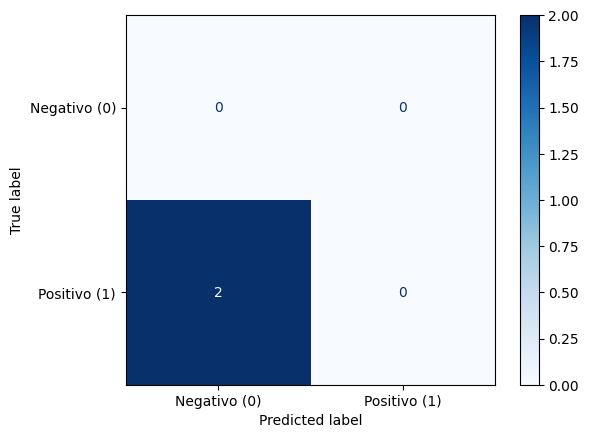

In [ ]:
# 5. Evaluar el Modelo
print("\n--- Evaluación del Modelo (Naive Bayes) ---")
print(classification_report(y_test, y_pred_nb, target_names=['Negativo (0)', 'Positivo (1)']))

# Matriz de Confusión
print("\nMatriz de Confusión:")
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Negativo (0)', 'Positivo (1)'])
disp_nb.plot(cmap=plt.cm.Blues)
plt.show()